# Data Analysis with Python  

This notebook explores several methods to analyze data and investigate whether certain characteristics or features can predict car prices. We will use various visualization and statistical techniques to understand relationships between different variables and the target variable (`price`).  


## **Dataset**  
The dataset is hosted on [IBM Cloud](https://cocl.us/DA101EN_object_storage).  


## **Table of Contents**  

1. [Import Data and Setup](#import-data)<br>
2. [Analyzing Individual Feature Patterns using Visualization](#feature-visualization)<br>
    2.1 [Correlation Analysis](#correlation)<br>
    2.2 [Continuous Numerical Variables](#continuous-variables)<br>
    2.3 [Categorical Variables](#categorical-variables)<br>
3. [Descriptive Statistical Analysis](#descriptive-analysis)<br>
4. [Basics of Grouping](#grouping)<br>
5. [Correlation and Causation](#correlation-causation)<br>
6. [ANOVA (Analysis of Variance)](#anova)<br>
7. [Conclusions](#conclusions)<br>

---


## 1. Import Data and Setup <a id="import-data"></a>  

We begin by importing necessary libraries and loading the dataset.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Load Data
path ='https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DA0101EN/automobileEDA.csv'
df = pd.read_csv(path)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


## 2. Analyzing Individual Feature Patterns using Visualization <a id="feature-visualization"></a>
Understanding the type of variable (numerical or categorical) is crucial for choosing the right visualization techniques. In this section, we examine feature patterns and relationships through visualizations.

### 2.1 Correlation Analysis <a id="correlation"></a>
Correlation measures the linear relationship between two numerical variables. It ranges from -1 to +1:

- **+1**: Strong positive linear relationship
- **0**: No linear relationship
- **-1**: Strong negative linear relationship


In [4]:
# Calculate correlation matrix for numerical variables
df.select_dtypes(include=['number']).corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008245,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055563,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158502,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.124139,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188829,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.062704,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167562,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.209523,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.008245,0.055563,0.158502,0.124139,0.188829,-0.062704,0.167562,0.209523,-0.055390,1.000000,0.187923,0.098462,-0.065713,-0.034696,-0.035201,0.082310,0.037300,0.241303,-0.241303


We can also check the correlation between specific variables:

In [3]:
df[['bore', 'stroke', 'compression-ratio', 'horsepower']].corr() 

,bore,stroke,compression-ratio,horsepower
bore,1.000000,-0.055390,0.001263,0.566936
stroke,-0.055390,1.000000,0.187923,0.098462
compression-ratio,0.001263,0.187923,1.000000,-0.214514
horsepower,0.566936,0.098462,-0.214514,1.000000


### 2.2 Continuous Numerical Variables <a id="continuous-variables"></a>
Continuous numerical variables can take any value within a range. Scatter plots with regression lines are useful for visualizing linear relationships.

#### Positive Linear Relationship

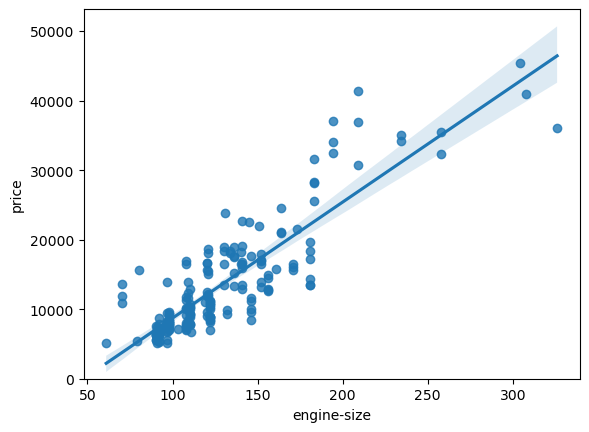

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


In [4]:
# Engine size as potential predictor variable of price
sns.regplot(data=df, x='engine-size', y='price')
plt.ylim(0,)
plt.show()

df[['engine-size', 'price']].corr()

The plot shows a strong positive correlation (≈ 0.87) between `engine-size` and `price`. Larger engine sizes generally correspond to higher prices.

#### Negative Linear Relationship

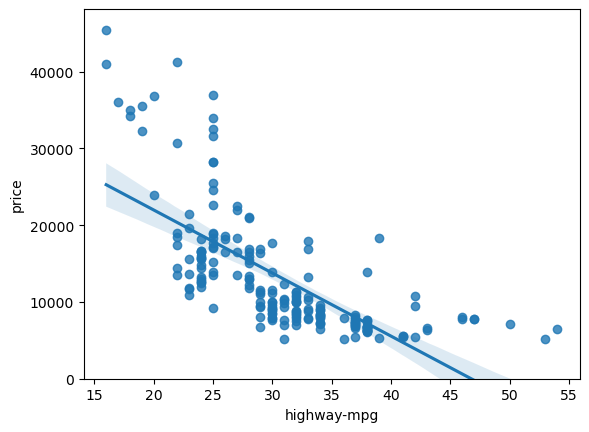

,highway-mpg,price
highway-mpg,1.000000,-0.704692
price,-0.704692,1.000000


In [7]:
sns.regplot(data=df, x='highway-mpg', y='price')
plt.ylim(0,)
plt.show()

df[['highway-mpg', 'price']].corr()

The plot indicates a negative correlation (≈ -0.704) between `highway-mpg` and `price`. Higher fuel efficiency is often associated with lower prices.

#### Weak Linear Relationship

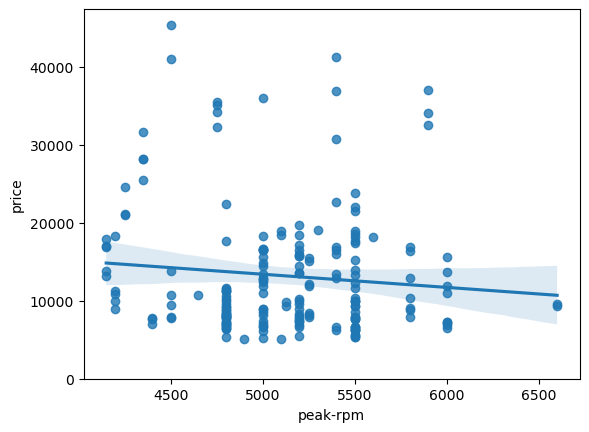

,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


In [8]:
sns.regplot(data=df, x='peak-rpm', y='price')
plt.ylim(0,)
plt.show()

df[['peak-rpm', 'price']].corr()

`Peak-rpm` has a weak correlation with price (≈ -0.101). The scattered data points indicate that it is not a strong predictor.

### 2.3 Categorical Variables <a id="categorical-variables"></a>
Categorical variables describe characteristics and are often visualized using boxplots.

**Column**: `body-style`

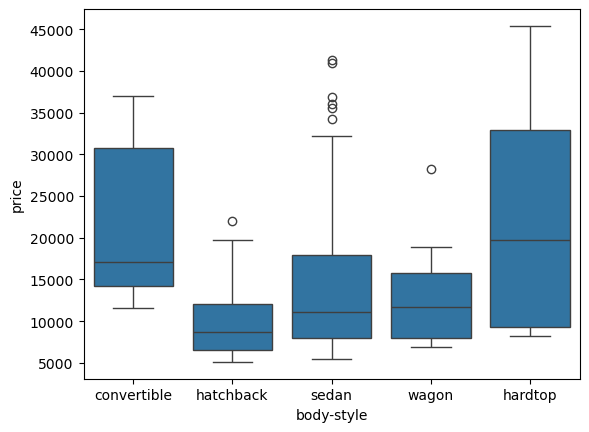

In [9]:
sns.boxplot(data=df, x='body-style', y='price')
plt.show()

The plot shows overlapping price distributions across different body styles, indicating that `body-style` may not be a strong predictor of `price`.
- The price ranges for different body styles, such as sedan, wagon, and hatchback, overlap significantly.
- For example, a sedan might have a similar price to a wagon or hatchback, which makes it difficult to differentiate body styles solely based on price.

A good predictor should show clear separation between categories in terms of the target variable (`price`). If there is significant overlap between the categories, the predictor (here, `body-style`) is less useful because:
- Many body styles share similar price ranges.
- Predicting the `price` based on `body-style` would result in large errors since prices vary widely within each category.
- In other words, if multiple body styles can have the same price, the model won't be able to confidently associate a particular price range with one specific `body-style`.


**Column**: `engine-location`


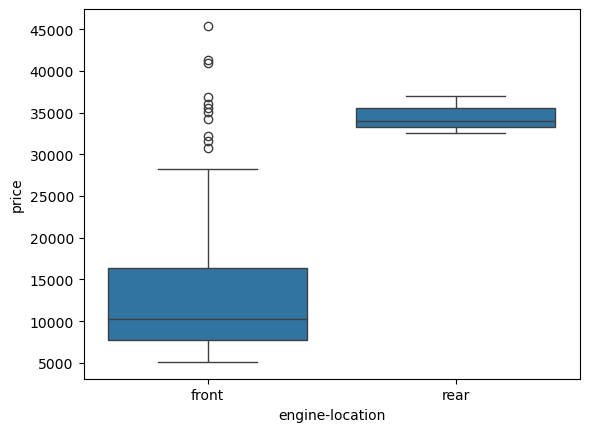

In [10]:
sns.boxplot(data=df, x='engine-location', y='price')
plt.show()

Cars with rear engines tend to have significantly higher prices, indicating that `engine-location` is a strong predictor of `price`. The distinct distributions of prices between cars with front and rear engines suggest that this feature plays a crucial role in determining car prices.
- **High price range (e.g., $35,000 – $40,000)**: Likely corresponds to cars with rear engines.
- **Lower price range**: These cars almost certainly have front engines.

This clear distinction between the two categories of `engine-location` (front vs. rear) makes it a valuable feature for a machine learning model. It can help the model easily differentiate between high-priced and low-priced cars, minimizing ambiguity and improving prediction accuracy.


**Column**: `drive-wheels`

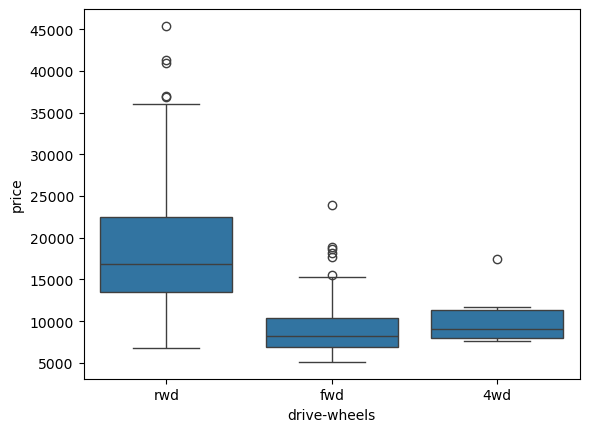

In [5]:
sns.boxplot(data=df, x='drive-wheels', y='price')
plt.show()

Predictive Power of `drive-wheels` might be Moderate:
- `rwd` cars generally have higher prices than `fwd` and `4wd` cars.
- However, price overlaps reduce the feature's predictive power.

## 3. Descriptive Statistical Analysis <a id="descriptive-analysis"></a>
The describe method provides summary statistics for numerical variables.

In [6]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,0.099502,0.900498
std,1.254802,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.319256,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,0.300083,0.300083
min,-2.000000,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,0.000000,1.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,0.000000,1.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.000000,1.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


We can also get statistics for categorical variables:

In [7]:
df.describe(include=['object'])

,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,201,201,201,201,201,201,201,201,201,200
unique,22,2,2,5,3,2,6,7,8,3
top,toyota,std,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,165,115,94,118,198,145,157,92,115


To understand the distribution of specific variables, we use `value_counts`.


In [8]:
df['drive-wheels'].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

We can convert the series to a Dataframe as follows:

In [9]:
df['drive-wheels'].value_counts().to_frame()

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


In [10]:
drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
drive_wheels_counts.reset_index(inplace=True)
drive_wheels_counts

,drive-wheels,count
0,fwd,118
1,rwd,75
2,4wd,8


## 4. Basics of Grouping <a id="grouping"></a>
The `groupby` method allows us to group data by one or more variables and perform aggregate operations.

In [11]:
df['drive-wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [12]:
df_group_one = df[['drive-wheels', 'price']].groupby('drive-wheels', as_index=False).mean()
df_group_one

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


In [17]:
df_gptest = df[['drive-wheels','body-style','price']]
grouped_test1 = df_gptest.groupby(['drive-wheels','body-style'], as_index=False).mean()
grouped_test1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


We can also create pivot tables for easier visualization:

In [18]:
# Pivot
grouped_pivot = grouped_test1.pivot(index='drive-wheels', columns='body-style')
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

In [19]:
grouped_pivot = grouped_pivot.fillna(0)
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

Map to visualize the relationship between Body Style vs Price.

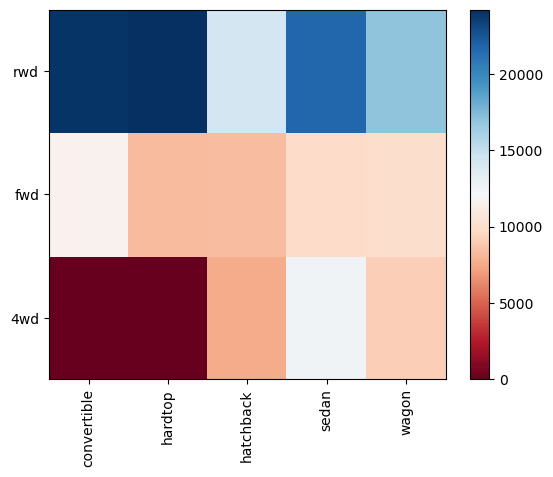

In [20]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

plt.xticks(rotation=90)
fig.colorbar(im)
plt.show()

## 5. Correlation and Causation <a id="correlation-causation"></a>
- **Correlation** measures the linear relationship between variables.
- **Causation** indicates that one variable directly affects another.

Correlation does not imply causation. We calculate the Pearson correlation coefficient to quantify linear dependence:

**P-value**: The P-value is the probability value that the correlation between these two variables is statistically significant. Normally, we choose a significance level of 0.05, which means that we are 95% confident that the correlation between the variables is significant.

By convention, when the
- **p-value $<$ 0.001**: we say there is strong evidence that the correlation is significant.
- **p-value $<$ 0.05**: there is moderate evidence that the correlation is significant.
- **p-value $<$ 0.1**: there is weak evidence that the correlation is significant.
- **p-value $>$ 0.1**: there is no evidence that the correlation is significant.

In [21]:
pearson_coef, p_value = stats.pearsonr(df['wheel-base'], df['price'])
print("The Pearson Correlation Coefficient is", round(pearson_coef, 3), " with a P-value =", p_value) 

The Pearson Correlation Coefficient is 0.585  with a P-value = 8.076488270732885e-20


Since the p-value is $<$ 0.001, the correlation between `wheel-base` and `price` is statistically significant, although the linear relationship isn't extremely strong (~0.585).

The P-value of 8.08e-20 is extremely small, meaning the correlation is statistically significant.
- The relationship is not due to random noise.
- Since it's significant, you can confidently say that the variable has some predictive power.

In [22]:
cols_analysis = ['horsepower', 'length', 'width', 'curb-weight', 'engine-size', 'bore', 'city-mpg', 'highway-mpg']

for col in cols_analysis:
    pearson_coef, p_value = stats.pearsonr(df[col], df['price'])
    print("Column: ", col)
    print("Pearson Correlation Coefficient: ", round(pearson_coef, 3))
    print("P-value: ", p_value)
    print("\n")
     

Column:  horsepower
Pearson Correlation Coefficient:  0.81
P-value:  6.369057428259557e-48


Column:  length
Pearson Correlation Coefficient:  0.691
P-value:  8.016477466158868e-30


Column:  width
Pearson Correlation Coefficient:  0.751
P-value:  9.20033551048144e-38


Column:  curb-weight
Pearson Correlation Coefficient:  0.834
P-value:  2.189577238893965e-53


Column:  engine-size
Pearson Correlation Coefficient:  0.872
P-value:  9.265491622197359e-64


Column:  bore
Pearson Correlation Coefficient:  0.543
P-value:  8.049189483935315e-17


Column:  city-mpg
Pearson Correlation Coefficient:  -0.687
P-value:  2.3211320655676474e-29


Column:  highway-mpg
Pearson Correlation Coefficient:  -0.705
P-value:  1.749547114447557e-31




The table below summarizes the correlations between various features and the `price`. Additionally, P-value significance levels are evaluated using the following convention:

- **P-value < 0.001**: Strong evidence of significant correlation.
- **P-value < 0.05**: Moderate evidence of significant correlation.
- **P-value < 0.1**: Weak evidence of significant correlation.
- **P-value > 0.1**: No evidence of significant correlation.

### **Correlation Table**

| Column          | Pearson Correlation | P-value             | Correlation Strength         | Significance                |
|-----------------|---------------------|---------------------|-----------------------------|-----------------------------|
| horsepower      | 0.81                | 6.37e-48            | Strong positive correlation  | Strong evidence (p < 0.001) |
| length          | 0.691               | 8.02e-30            | Moderate-to-strong positive | Strong evidence (p < 0.001) |
| width           | 0.751               | 9.20e-38            | Strong positive correlation  | Strong evidence (p < 0.001) |
| curb-weight     | 0.834               | 2.19e-53            | Very strong positive         | Strong evidence (p < 0.001) |
| engine-size     | 0.872               | 9.27e-64            | Extremely strong positive    | Strong evidence (p < 0.001) |
| bore            | 0.543               | 8.05e-17            | Moderate positive correlation| Strong evidence (p < 0.001) |
| city-mpg        | -0.687              | 2.32e-29            | Strong negative correlation  | Strong evidence (p < 0.001) |
| highway-mpg     | -0.705              | 1.75e-31            | Strong negative correlation  | Strong evidence (p < 0.001) |


### **Feature Analysis**

#### **Horsepower**
There is a **strong positive correlation** between `horsepower` and `price`. As horsepower increases, prices tend to increase significantly. This feature is a valuable predictor of car prices.

#### **Length**
`length` shows a **moderate-to-strong positive correlation** with price. Longer vehicles generally tend to have higher prices, likely because larger cars often have more features or capacity.

#### **Width**
`width` has a **strong positive correlation** with price. Wider cars may correspond to luxury or larger vehicles, which justifies the higher prices.

#### **Curb-Weight**
`curb-weight` has a **very strong positive correlation** with price. Heavier cars are often associated with more powerful engines and better build quality, contributing to higher prices.

#### **Engine Size**
`engine-size` has an **extremely strong positive correlation** with price, making it one of the most important predictors. Larger engines generally indicate higher performance and luxury, leading to higher prices.

#### **Bore**
`bore` shows a **moderate positive correlation** with price. It suggests that larger bore sizes are associated with higher engine performance and thus higher prices.

#### **City-MPG**
There is a **strong negative correlation** between `city-mpg` and price. Higher city fuel efficiency is typically associated with smaller, less expensive cars.

#### **Highway-MPG**
Similar to `city-mpg`, `highway-mpg` has a **strong negative correlation** with price. Cars with high highway fuel efficiency are often designed for budget-conscious consumers, resulting in lower prices.


### **Recommendations**
- **Engine size**, **curb-weight**, **horsepower**, and **width** are the most significant predictors of car price due to their high positive correlations and strong statistical significance.
- **City-mpg** and **highway-mpg** are strong negative predictors of price, providing complementary information for models.
- Variables with lower but significant correlations, such as `bore`, may still provide value in multivariate models.


## 6. ANOVA (Analysis of Variance) <a id="anova"></a>
ANOVA tests whether there are significant differences between the means of multiple groups. It returns:

- **F-test score**: Measures the variability between group means.
- **P-value**: Indicates statistical significance.
    

In [23]:
df_gptest

,drive-wheels,body-style,price
0,rwd,convertible,13495.0
1,rwd,convertible,16500.0
2,rwd,hatchback,16500.0
3,fwd,sedan,13950.0
4,4wd,sedan,17450.0
...,...,...,...
196,rwd,sedan,16845.0
197,rwd,sedan,19045.0
198,rwd,sedan,21485.0
199,rwd,sedan,22470.0


In [24]:
df_gptest['drive-wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [25]:
grouped_test2 = df_gptest[['drive-wheels', 'price']].groupby(['drive-wheels'])
grouped_test2

In [26]:
grouped_test2.get_group(('4wd',))['price']

4      17450.0
136     7603.0
140     9233.0
141    11259.0
144     8013.0
145    11694.0
150     7898.0
151     8778.0
Name: price, dtype: float64

In [27]:
# ANOVA
f_val, p_val = stats.f_oneway(
    grouped_test2.get_group(('fwd',))['price'],
    grouped_test2.get_group(('rwd',))['price'],
    grouped_test2.get_group(('4wd',))['price']
)
print("ANOVA results: F =", f_val, ", P =", p_val)

ANOVA results: F = 67.95406500780399 , P = 3.3945443577151245e-23


This is a great result, with a large **F-test score** showing a strong correlation and a **P-value** of almost 0, implying almost certain statistical significance.

#### **F-statistic of 67.95**: 
A large F-statistic indicates that the **between-group variability** (differences between the means of the groups) is much larger than the **within-group variability** (variations within each group).
- In other words, the means of the price for different drive-wheel categories (**fwd**, **rwd**, and **4wd**) are likely significantly different.

#### **P-value of 3.39e-23**: 
This is an **extremely small value** (essentially 0).

- **P-value < 0.001**: This shows **strong evidence** that the difference in means between the groups is statistically significant.
- Based on this result, you can **reject the null hypothesis**, which states that all the group means are equal.


#### **Null hypothesis**: 
The **null hypothesis** in **ANOVA** assumes that all group means are equal:
$$
\text{The average car price is the same for all three drive-wheel categories  (fwd, rwd, and 4wd).}
$$
When you perform an **ANOVA test**, you are trying to determine whether there are statistically significant differences between the group means.

- **Small P-value (e.g., 3.39e-23)**:
    - A very small **P-value** indicates that the observed differences between the group means are **unlikely to have occurred by random chance**.
    - Therefore, **you can reject the null hypothesis**, which suggests that there is **strong evidence** that:
        - At least one of the drive-wheel categories (**fwd**, **rwd**, or **4wd**) has a mean price that is significantly different from the others.

- **Important Note**:
    - **Rejecting the null hypothesis** only tells you that **some difference exists** between the groups.
    - However, it **does not tell you exactly which groups** are different.
        - To identify which specific categories differ, you would need to perform **further tests**, such as **pairwise comparisons** (e.g., **Tukey's test**).


In [28]:
f_val, p_val = stats.f_oneway(
    grouped_test2.get_group(('fwd',))['price'],
    grouped_test2.get_group(('rwd',))['price'],
)
print("fwd, rwd:")
print("ANOVA results: F =", f_val, ", P =", p_val)

f_val, p_val = stats.f_oneway(
    grouped_test2.get_group(('fwd',))['price'],
    grouped_test2.get_group(('4wd',))['price']
)
print("fwd, 4wd")
print("ANOVA results: F =", f_val, ", P =", p_val)

f_val, p_val = stats.f_oneway(
    grouped_test2.get_group(('rwd',))['price'],
    grouped_test2.get_group(('4wd',))['price']
)
print("rwd, 4wd")
print("ANOVA results: F =", f_val, ", P =", p_val)

fwd, rwd:
ANOVA results: F = 130.5533160959111 , P = 2.2355306355677845e-23
fwd, 4wd
ANOVA results: F = 0.6654657502523033 , P = 0.41620116697845666
rwd, 4wd
ANOVA results: F = 8.580681368924756 , P = 0.004411492211225333


### **fwd vs. rwd**
- The **P-value** is extremely small, indicating a **statistically significant** difference between the average prices of **fwd** and **rwd** drive types.
- The large **F-statistic** supports this conclusion, meaning the difference between the group means is much greater than the variation within the groups.

### **fwd vs. 4wd**
- The **P-value** is greater than 0.05, indicating **no significant difference** between the average prices of **fwd** and **4wd** drive types.
- The low **F-statistic** confirms that there is minimal variability between the group means.

### **rwd vs. 4wd**
- The **P-value** is less than 0.05, indicating a **statistically significant difference** between the average prices of **rwd** and **4wd** drive types.
- The **F-statistic** shows moderate variability between the group means compared to within-group variability.

## 7. Conclusions <a id="conclusions"></a>
- The **fwd** and **rwd** groups have a **highly significant difference** in prices.
- There is **no significant difference** in prices between **fwd** and **4wd**.
- The **rwd** and **4wd** groups show a **statistically significant difference** in prices, but the difference is less pronounced than between **fwd** and **rwd**.

---

### **ANOVA Results Summary**
- **fwd vs. rwd**: Significant
- **rwd vs. 4wd**: Significant
- **fwd vs. 4wd**: Not significant

This indicates that **drive-wheels** may capture important information about the `price` in some cases.


### **Why `drive-wheels` Can Be Useful in a Prediction Model:**
- **Significant differences** exist between some categories (fwd vs. rwd, rwd vs. 4wd).
- It can **complement other features** by capturing categorical differences related to drivetrain (e.g., luxury cars may have rwd).
- It is **not redundant** if multicollinearity is low, ensuring it adds unique value to a prediction model.
